In [1]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices('GPU')

vram_limit = 10240

if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit = vram_limit)]
        )
        print(f"VRAM capped at {vram_limit} MB")
    except RuntimeError as e:
        print(e)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (60000, 28, 28, 1) (60000,)
Test: (10000, 28, 28, 1) (10000,)


In [2]:
baseline_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

baseline_loss, baseline_test_acc = baseline_model.evaluate(
    X_test, y_test, verbose=0
)

print("Baseline test accuracy:", baseline_test_acc)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.8046 - loss: 0.5398 - val_accuracy: 0.8620 - val_loss: 0.3846
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8717 - loss: 0.3570 - val_accuracy: 0.8811 - val_loss: 0.3292
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8872 - loss: 0.3087 - val_accuracy: 0.8878 - val_loss: 0.3064
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8991 - loss: 0.2755 - val_accuracy: 0.8891 - val_loss: 0.2965
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9075 - loss: 0.2524 - val_accuracy: 0.8970 - val_loss: 0.2838
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9140 - loss: 0.2325 - val_accuracy: 0.9042 - val_loss: 0.2600
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9225 - loss: 0.2129 - val_accuracy: 0.9078 - val_loss: 0.2574
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9278 - loss: 0.1966 - val_accu

In [3]:
regularized_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(10, activation="softmax")
])

regularized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

regularized_history = regularized_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

reg_loss, reg_test_acc = regularized_model.evaluate(
    X_test, y_test, verbose=0
)

print("Regularized test accuracy:", reg_test_acc)
print("Epochs actually run:", len(regularized_history.history["loss"]))

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.7693 - loss: 0.6285 - val_accuracy: 0.8550 - val_loss: 0.4007
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8522 - loss: 0.4138 - val_accuracy: 0.8734 - val_loss: 0.3475
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8717 - loss: 0.3561 - val_accuracy: 0.8823 - val_loss: 0.3182
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8826 - loss: 0.3246 - val_accuracy: 0.8932 - val_loss: 0.2953
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8893 - loss: 0.3038 - val_accuracy: 0.8957 - val_loss: 0.2864
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8976 - loss: 0.2790 - val_accuracy: 0.8997 - val_loss: 0.2757
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9032 - loss: 0.2655 - val_accuracy: 0.9055 - val_loss: 0.2564
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9094 - loss: 0.2472 - 

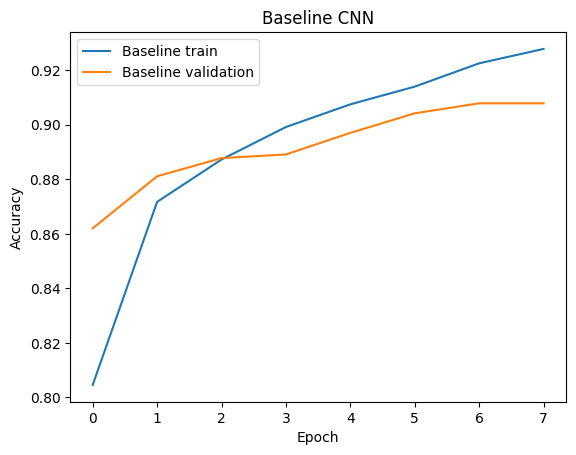

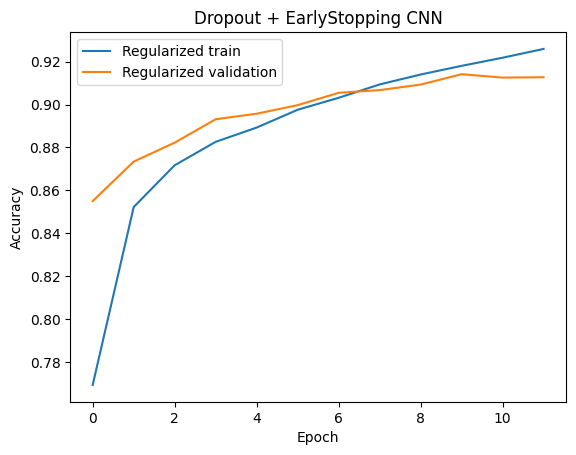

In [4]:
plt.plot(baseline_history.history["accuracy"], label="Baseline train")
plt.plot(baseline_history.history["val_accuracy"], label="Baseline validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN")
plt.legend()
plt.show()

plt.plot(regularized_history.history["accuracy"], label="Regularized train")
plt.plot(regularized_history.history["val_accuracy"], label="Regularized validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout + EarlyStopping CNN")
plt.legend()
plt.show()

In [5]:
l2_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dense(10, activation="softmax")
])

l2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

l2_history = l2_model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

l2_loss, l2_test_acc = l2_model.evaluate(X_test, y_test, verbose=0)
print("L2 test accuracy:", l2_test_acc)

Epoch 1/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.8008 - loss: 0.6288 - val_accuracy: 0.8561 - val_loss: 0.4683
Epoch 2/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8688 - loss: 0.4280 - val_accuracy: 0.8767 - val_loss: 0.4081
Epoch 3/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8820 - loss: 0.3796 - val_accuracy: 0.8874 - val_loss: 0.3569
Epoch 4/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8917 - loss: 0.3461 - val_accuracy: 0.8898 - val_loss: 0.3503
Epoch 5/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8987 - loss: 0.3278 - val_accuracy: 0.8953 - val_loss: 0.3360
Epoch 6/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9024 - loss: 0.3138 - val_accuracy: 0.8973 - val_loss: 0.3333
Epoch 7/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9072 - loss: 0.3015 - val_accuracy: 0.8884 - val_loss: 0.3490
Epoch 8/8
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9107 - loss: 0.2923 - val_accu

In [6]:
model_lr_small = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_lr_small.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lr_small = model_lr_small.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

loss_small, acc_small = model_lr_small.evaluate(X_test, y_test, verbose=0)
print("lr=0.0001 test accuracy:", acc_small)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.6985 - loss: 0.9137 - val_accuracy: 0.7821 - val_loss: 0.5761
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8061 - loss: 0.5294 - val_accuracy: 0.8183 - val_loss: 0.5019
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8310 - loss: 0.4700 - val_accuracy: 0.8424 - val_loss: 0.4482
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8473 - loss: 0.4356 - val_accuracy: 0.8528 - val_loss: 0.4280
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8540 - loss: 0.4125 - val_accuracy: 0.8555 - val_loss: 0.4155
lr=0.0001 test accuracy: 0.8493000268936157


In [7]:
model_lr_large = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_lr_large.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_lr_large = model_lr_large.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

loss_large, acc_large = model_lr_large.evaluate(X_test, y_test, verbose=0)
print("lr=0.01 test accuracy:", acc_large)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8267 - loss: 0.4687 - val_accuracy: 0.8615 - val_loss: 0.3800
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8753 - loss: 0.3368 - val_accuracy: 0.8767 - val_loss: 0.3523
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8885 - loss: 0.3044 - val_accuracy: 0.8808 - val_loss: 0.3217
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8895 - loss: 0.2942 - val_accuracy: 0.8893 - val_loss: 0.3101
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8965 - loss: 0.2809 - val_accuracy: 0.8870 - val_loss: 0.3073
lr=0.01 test accuracy: 0.8840000033378601


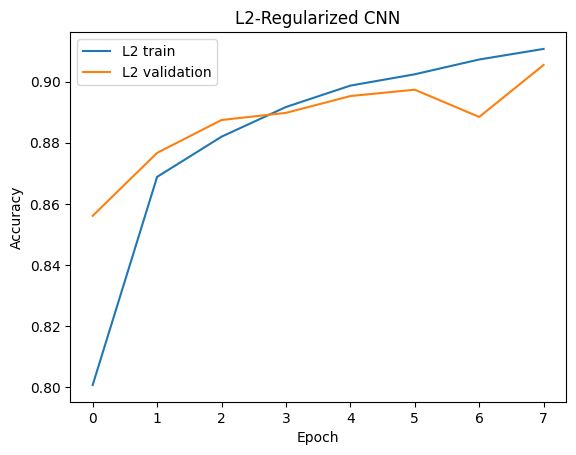

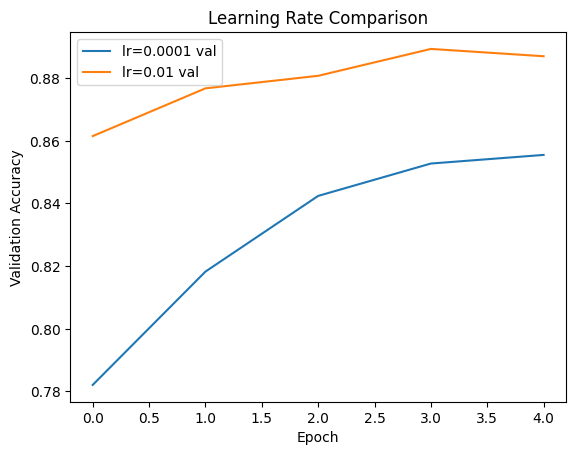

In [8]:
plt.plot(l2_history.history["accuracy"], label="L2 train")
plt.plot(l2_history.history["val_accuracy"], label="L2 validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L2-Regularized CNN")
plt.legend()
plt.show()

plt.plot(history_lr_small.history["val_accuracy"], label="lr=0.0001 val")
plt.plot(history_lr_large.history["val_accuracy"], label="lr=0.01 val")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [14]:
import gc
gc.collect()
keras.backend.clear_session()